# sampley exemplar: Stage 2
Before going through this exemplar, please consult the Introduction to sampley exemplars (```intro.ipynb```).
<br>This exemplar illustrates the classes that can be made in Stage 2, their class methods, their attributes, and their methods. 

## Setup

### Import the package

In [1]:
from sampley import *

### Set the import folder
To run this exemplar, download the mock data files, put them in a folder, and set the path to the folder below.

In [2]:
import_folder = './import/'

### Set the export folder
To run this exemplar, make a folder to save the samples in and set the path to the folder below.

In [3]:
export_folder = './export/'

### Make DataPoints and Sections objects (Stage 1)
Before making any objects in Stage 2, we, of course, have to conduct Stage 1. For the sake of this exemplar, we make one ```Sections``` and one ```DataPoints``` object below that are then used to make all the subsequent delimiters. See the Stage 1 exemplar and the User Manual for more details.

In [4]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [5]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: section IDs generated.


## Periods

### Make a ```Periods``` object...
We can make a ```Periods``` object with the ```Periods.delimit()``` class method. In practice, the first is the most likely to be used.
<br>There are two options for the parameter ```extent```, illustrated in the two examples below.

Firstly, we can make a ```Periods``` object from a ```DataPoints``` or ```Sections``` object.
<br>In this example, we use the ```Sections``` object that we made before.

In [6]:
u_periods = Periods.delimit(
    extent=u_sections,
    unit='day',
    num=8)

Secondly, we can make a ```Periods``` object from a tuple containing two elements:
- a list of two dates/datetimes marking the beginning and end of the study, respectively
- the timezone of the dates/datetimes

In [7]:
u_periods = Periods.delimit(
    extent=(['2019-01-25 10:18:13', '2019-03-03 14:32:57'], 'UTC-05:00'),
    unit='day',
    num=8)

Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".


### Access a ```Periods``` object's attributes
A ```Periods``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```periods```) that we can access as follows.

In [8]:
u_periods.name

'periods-8d'

In [9]:
u_periods.parameters

{'periods_tz': 'UTC-05:00',
 'periods_extent': '2019-01-25-2019-03-05',
 'periods_extent_source': 'tuple',
 'periods_number': 8,
 'periods_unit': 'day'}

In [10]:
u_periods.periods

,period_id,date_beg,date_mid,date_end
0,p2019-01-25-8d,2019-01-25 00:00:00-05:00,2019-01-29 00:00:00-05:00,2019-02-01 00:00:00-05:00
1,p2019-02-02-8d,2019-02-02 00:00:00-05:00,2019-02-06 00:00:00-05:00,2019-02-09 00:00:00-05:00
2,p2019-02-10-8d,2019-02-10 00:00:00-05:00,2019-02-14 00:00:00-05:00,2019-02-17 00:00:00-05:00
3,p2019-02-18-8d,2019-02-18 00:00:00-05:00,2019-02-22 00:00:00-05:00,2019-02-25 00:00:00-05:00
4,p2019-02-26-8d,2019-02-26 00:00:00-05:00,2019-03-02 00:00:00-05:00,2019-03-05 00:00:00-05:00


### Save a ```Periods``` object
```Periods``` objects have an inbuilt ```save``` method to save the periods as a CSV.

In [11]:
u_periods.save(folder=export_folder)

## Cells

### Make a ```Cells``` object...
We can make a ```Cells``` object with the ```Cells.delimit()``` class method.
<br>There are three options for the parameter ```extent```, illustrated in the three examples below. In practice, the first two are the most likely to be used.

Firstly, we can make a ```Cells``` object from a ```DataPoints``` or ```Sections``` object.
<br>In this example, we use the ```Sections``` object that we made before.

In [12]:
u_cells = Cells.delimit(
    extent=u_sections,
    var='hexagonal',
    side=5000,
    buffer=2000)

Secondly, we can make a ```Cells``` object from a GeoPackage or Shapefile by, first, importing it as a ```GeoDataFrame``` with the GeoPandas ```gpd.read_file()``` function and, then, using the ```GeoDataFrame``` as the extent. The GeoPackage or Shapefile could represent, for example, the study area covered by the surveys.
<br>In this example, we use a file called ```study_area.gpkg``` which is a simple rectangle , however, the shape could be more complex.

In [13]:
import geopandas as gpd  # import geopandas package
study_area = gpd.read_file(import_folder + 'study_area.gpkg')  # import the GeoPackage as a GeoDataFrame
u_cells = Cells.delimit(
    extent=study_area,
    var='hexagonal',
    side=5000,
    buffer=2000)

Finally, we can also make a ```Cells``` object from a tuple containing two elements:
- a list of four coordinates marking the x min, y min, x max, y max of the study area respectively
- the CRS of the coordinates

In [14]:
from pyproj import CRS
u_cells = Cells.delimit(
    extent=([500095.61955057, 4696798.08683991, 657711.42048071, 4751214.73038492], CRS('EPSG:32619')),
    var='hexagonal',
    side=5000,
    buffer=2000)

### Access a ```Cells``` object's attributes
A ```Cells``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```cells```) that we can access as follows.

In [15]:
u_cells.name

'cells-h5000m'

In [16]:
u_cells.parameters

{'cells_crs': 'EPSG:32619',
 'cells_extent': '493765.4925316478, 4689798.08683991, 671300.7003074577, 4759798.08683991',
 'cells_extent_source': 'tuple',
 'cells_var': 'hexagonal',
 'cells_side': 5000,
 'cells_unit': 'metre',
 'cells_buffer': 2000}

In [17]:
u_cells.cells

,cell_id,polygon,centroid
0,c001-h5000m,"POLYGON ((498095.62 4699798.087, 502425.747 46...",POINT (498095.62 4694798.087)
1,c002-h5000m,"POLYGON ((506755.874 4699798.087, 511086.001 4...",POINT (506755.874 4694798.087)
2,c003-h5000m,"POLYGON ((515416.128 4699798.087, 519746.255 4...",POINT (515416.128 4694798.087)
3,c004-h5000m,"POLYGON ((524076.382 4699798.087, 528406.509 4...",POINT (524076.382 4694798.087)
4,c005-h5000m,"POLYGON ((532736.636 4699798.087, 537066.763 4...",POINT (532736.636 4694798.087)
...,...,...,...
175,c176-h5000m,"POLYGON ((627999.43 4759798.087, 632329.557 47...",POINT (627999.43 4754798.087)
176,c177-h5000m,"POLYGON ((636659.684 4759798.087, 640989.811 4...",POINT (636659.684 4754798.087)
177,c178-h5000m,"POLYGON ((645319.938 4759798.087, 649650.065 4...",POINT (645319.938 4754798.087)
178,c179-h5000m,"POLYGON ((653980.192 4759798.087, 658310.319 4...",POINT (653980.192 4754798.087)


### Plot a ```Cells``` object
```Cells``` objects have an inbuilt ```plot``` method to make a simple plot.

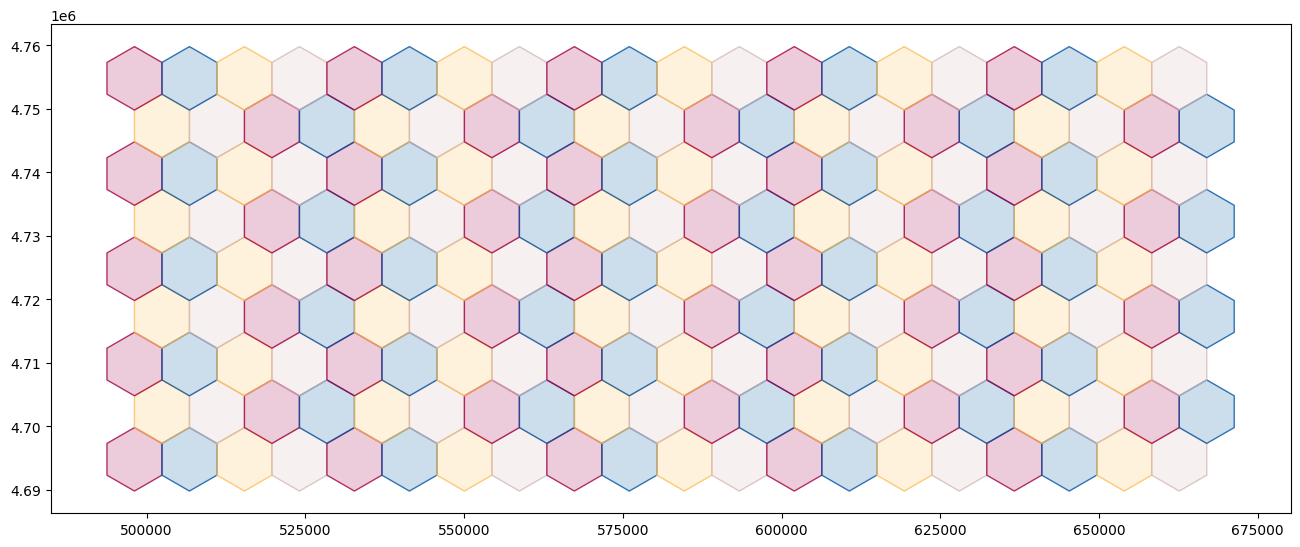

In [18]:
u_cells.plot()

### Save a ```Cells``` object
```Cells``` objects have an inbuilt ```save``` method to save the cells as a GPKG.

In [19]:
u_cells.save(folder=export_folder)

## Segments

### Make a ```Segments``` object...
We can make a ```Segments``` object from a ```Sections``` object with the ```Segments.delimit()``` class method.

In [20]:
u_segments = Segments.delimit(
    sections=u_sections,
    var='simple',
    target=10000,
    rand=True)

### Access a ```Segments``` object's attributes
A ```Segments``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```segments```) that we can access as follows.

In [21]:
u_segments.name

'segments-s10000m'

In [22]:
u_segments.parameters

{'sections_name': 'sections-sections',
 'segments_crs': 'EPSG:32619',
 'segments_var': 'simple',
 'segments_rand': True,
 'segments_target': 10000,
 'segments_unit': 'metre'}

In [23]:
u_segments.segments

,segment_id,line,midpoint,date,section_id,dfbsec_beg,dfbsec_end
0,s01-s10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.311 4742845.962),2019-01-25,s1,0.000000,10000.000000
1,s02-s10000m,"LINESTRING (570094.222 4742829.916, 569917.081...",POINT (565094.73 4742799.725),2019-01-25,s1,10000.000000,20000.000000
2,s03-s10000m,"LINESTRING (560095.148 4742773.163, 559864.339...",POINT (555095.521 4742749.119),2019-01-25,s1,20000.000000,30000.000000
3,s04-s10000m,"LINESTRING (550095.667 4742710.935, 550091.025...",POINT (550093.346 4742710.918),2019-01-25,s1,30000.000000,30004.642260
4,s05-s10000m,"LINESTRING (550091.025 4742710.901, 549838.842...",POINT (545091.144 4742676.352),2019-01-25,s1,30004.642260,40004.642260
...,...,...,...,...,...,...,...
68,s69-s10000m,"LINESTRING (652338.76 4697682.02, 652197.878 4...",POINT (647339.987 4697611.472),2019-03-05,s4,274105.324868,284105.324868
69,s70-s10000m,"LINESTRING (642341.15 4697526.723, 641994.147 ...",POINT (637342.194 4697445.552),2019-03-05,s4,284105.324868,294105.324868
70,s71-s10000m,"LINESTRING (632343.125 4697349.07, 632326.134 ...",POINT (627344.065 4697254.461),2019-03-05,s4,294105.324868,304105.324868
71,s72-s10000m,"LINESTRING (622345.629 4697147.973, 622000.67 ...",POINT (617346.364 4697062.225),2019-03-05,s4,304105.324868,314105.324868


### Plot a ```Segments``` object
```Segments``` objects have an inbuilt ```plot``` method to make a simple plot.

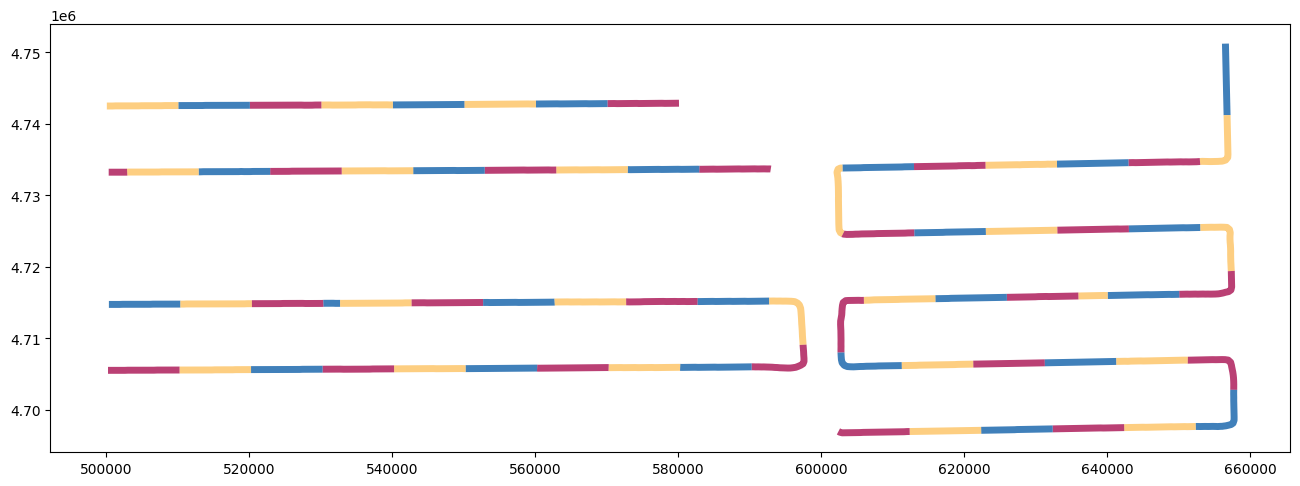

In [24]:
u_segments.plot()

### Save a ```Segments``` object
```Segments``` objects have an inbuilt ```save``` method to save the segments as a GPKG.

In [25]:
u_segments.save(folder=export_folder)

## Presences

### Make a ```Presences``` object...
We can make a ```Presences``` object from a ```DataPoints``` object with the ```Presences.delimit()``` class method.

In [26]:
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')

### Access a ```Presences``` object's attributes
A ```Presences``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```presences```). We can access the attributes as follows.

In [27]:
u_presences.name

'presences-sightings'

In [28]:
u_presences.parameters

{'presences_crs': 'EPSG:32619'}

In [29]:
u_presences.presences

,point_id,point,date,datapoint_id
0,p01,POINT (579166.78 4742872.701),2019-01-25,d01
1,p02,POINT (554184.217 4742741.886),2019-01-25,d02
2,p03,POINT (548599.876 4742700.214),2019-01-25,d03
3,p04,POINT (520909.741 4714855.058),2019-03-02,d04
4,p05,POINT (532548.249 4714899.835),2019-03-02,d05
5,p06,POINT (512817.407 4705582.465),2019-03-02,d06
6,p07,POINT (504710.41 4705553.392),2019-03-02,d07
7,p08,POINT (654449.136 4716189.584),2019-03-05,d08
8,p09,POINT (645666.237 4716110.937),2019-03-05,d09
9,p10,POINT (643532.681 4716066.52),2019-03-05,d10


### Plot a ```Presences``` object
```Presences``` objects have an inbuilt ```plot``` method to make a simple plot.

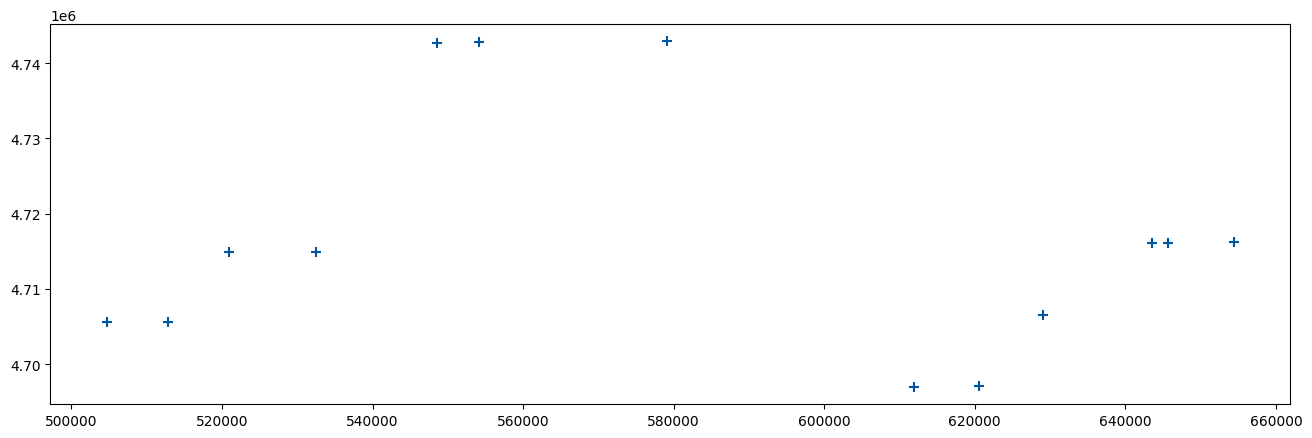

In [30]:
u_presences.plot()

### Save a ```Presences``` object
```Presences``` objects have an inbuilt ```save``` method to save the presences as a GPKG.

In [31]:
u_presences.save(folder=export_folder)

## PresenceZones
Please note: the Presences section of this notebook must be run before running this section

### Make a ```PresenceZones``` object...
We can make a ```PresenceZones``` object from a ```Sections``` object and a ```Presences``` object with the ```PresenceZones.delimit()``` class method.

In [32]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=5,
    tm_unit='day',
)

### Access a ```PresenceZones``` object's attributes
A ```PresenceZones``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```presencezones```) that we can access as follows.

In [33]:
u_presencezones.name

'presencezones-10000m-5day'

In [34]:
u_presencezones.parameters

{'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 5,
 'presencezones_tm_unit': 'day'}

In [35]:
u_presencezones.presencezones

,section_id,presencezones
0,s1,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
1,s2,"MULTIPOLYGON (((550550.779 4732892.362, 549580..."
2,s3,"MULTIPOLYGON (((613927.76 4687166.258, 612957...."
3,s4,"MULTIPOLYGON (((613927.76 4687166.258, 612957...."


### Plot a ```PresenceZones``` object
```PresenceZones``` objects have an inbuilt ```plot``` method to make a simple plot.

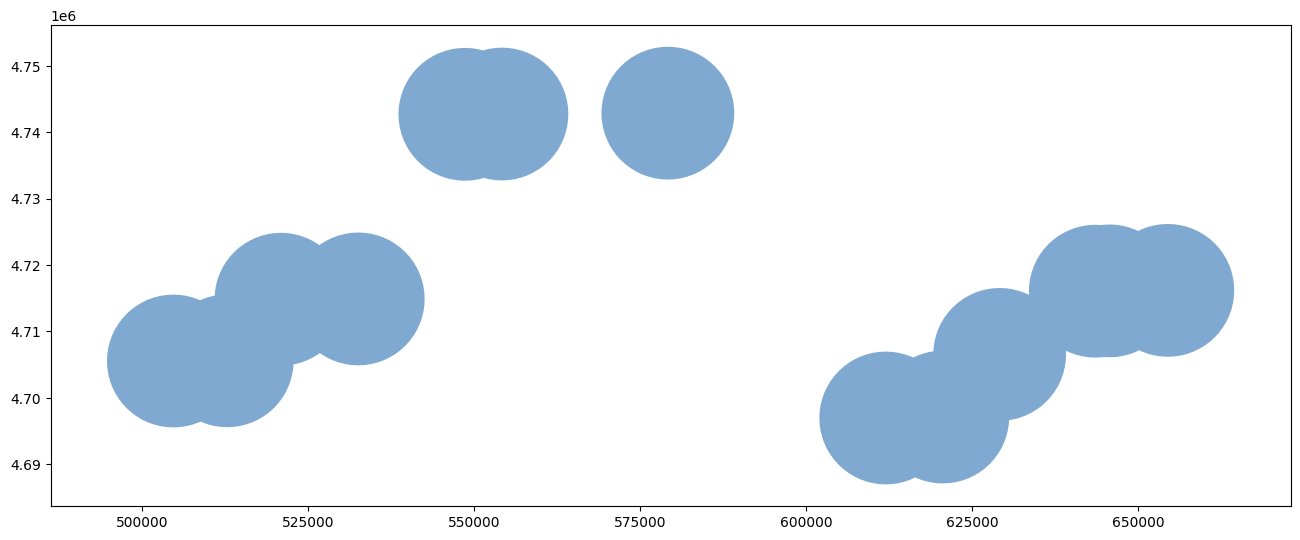

In [36]:
u_presencezones.plot()

### Save a ```PresenceZones``` object
```PresenceZones``` objects have an inbuilt ```save``` method to save the presence zones as a GPKG.

In [37]:
u_presencezones.save(folder=export_folder)

## Absences
Please note: the PresenceZones sections of this notebook must be run before running this section

### Make an ```Absences``` object...
We can make an ```Absences``` object from a ```Sections``` object and a ```PresenceZones``` object with the ```Absences.delimit()``` class method.

In [38]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='along',
    target=20)

Target: 20 | Attempts: 31 | Successes: 20


### Access an ```Absences``` object's attributes
An ```Absences``` object, regardless of how it was made, will have three attributes (```name```, ```parameters```, and ```absences```). We can access the attributes as follows.

In [39]:
u_absences.name

'absences-as-10000m-5day'

In [40]:
u_absences.parameters

{'absences_var': 'along',
 'absences_target': 20,
 'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 5,
 'presencezones_tm_unit': 'day'}

In [41]:
u_absences.absences

,point_id,point,date,section_id,dfbs
0,a01,POINT (564318.343 4742792.428),2019-01-25,s1,15776.420795
1,a02,POINT (528689.986 4742607.374),2019-01-25,s1,51408.086203
2,a03,POINT (585013.771 4733664.979),2019-01-30,s2,87921.120058
3,a04,POINT (574671.107 4733604.645),2019-01-30,s2,98265.000833
4,a05,POINT (559936.622 4733535.472),2019-01-30,s2,113001.012803
5,a06,POINT (519723.393 4733322.454),2019-01-30,s2,153216.661836
6,a07,POINT (576759.039 4715155.469),2019-03-02,s3,248972.794333
7,a08,POINT (594876.565 4715212.688),2019-03-02,s3,267093.518723
8,a09,POINT (564662.199 4705870.727),2019-03-02,s3,310514.551424
9,a10,POINT (549527.851 4705783.353),2019-03-02,s3,325650.083131


### Plot an ```Absences``` object
```Absences``` objects have an inbuilt ```plot``` method to make a simple plot.

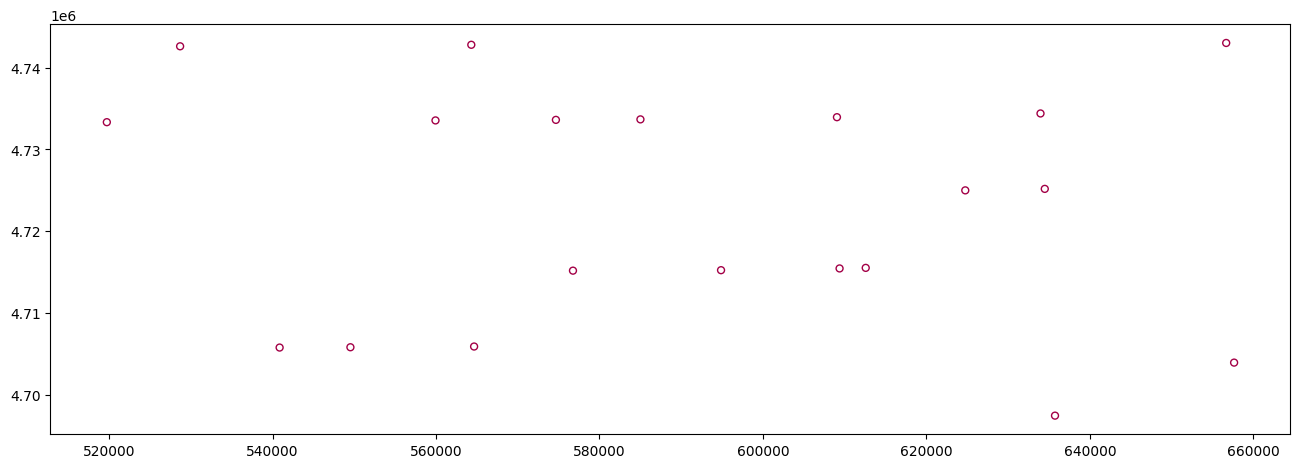

In [42]:
u_absences.plot()

### Save an ```Absences``` object
```Absences``` objects have an inbuilt ```save``` method to save the absences as a GPKG.

In [43]:
u_absences.save(folder=export_folder)